### analize simulation data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import re

# for bessel functions and curve fitting
from scipy.optimize import curve_fit
from scipy import special

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Latin Modern Roman"],  # must be installed on your system
    "mathtext.fontset": "cm",             # Computer Modern math, matches LaTeX style
    "text.usetex": True,                    # render text via LaTeX
    "text.latex.preamble": r"\usepackage{amssymb}"
})

In [9]:
from readTLMData import TLMREADER
folder_path = r"K:\tech_stud\Hager_Lutz\Master\Data\Simulation\IVdata_L=150_doping=4e18_thickness=150_rho=1e-5"

list_of_measurements = TLMREADER(folder_path).get_simulation_data()
list_of_measurements = dict(sorted(list_of_measurements.items()))

r_inner = 150
distances = list(map(int, list_of_measurements.keys()))
print(distances)

[40, 50, 60, 70, 80, 90, 100, 160, 240, 320, 400, 480]


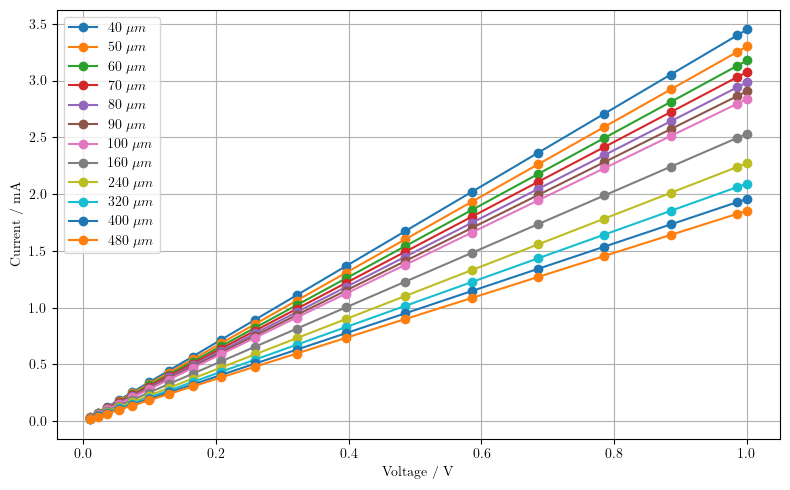

In [ ]:
plt.figure(figsize=(8, 5))

for key in list_of_measurements.keys():
    plt.plot(list_of_measurements[key]['Voltage'], list_of_measurements[key]['Current'], 'o-', label=f"{key} $\\mu m$")

plt.xlabel("Voltage / V")
plt.ylabel("Current / mA")
# plt.xlim(-0.5, 0.5)
# plt.title(name)
plt.grid(True)
plt.legend()
plt.tight_layout()
# plt.savefig(os.path.join(folder_path, 'IV_plot.pdf'), dpi=300)
plt.show()
# plt.savefig(os.path.join(folder_path, 'IV.png'), bbox_inches='tight')

In [7]:
def get_lin_fit(x, y):
    slope, intercept = np.polyfit(x, y, 1)
    y_fit = slope * x + intercept
    r_squared = 1- np.sum((y - y_fit)**2)/(np.sum((y - np.mean(y))**2)) # R^2 = 1 - SS_res / SS_tot = 1 - (y-y_fit)^2/(y-mean(y))^2

    return slope, intercept, r_squared

In [8]:
R_list = []
for key in list_of_measurements.keys():
    slope, intercept, r_squared = get_lin_fit(list_of_measurements[key]['Voltage'], list_of_measurements[key]['Current'])
    R_list.append((1/slope))  # in ohm
print(R_list)

[np.float64(0.2897599303764561), np.float64(0.30277310452690703), np.float64(0.3146242049296703), np.float64(0.32496657416336294), np.float64(0.3348891189094556), np.float64(0.34390253755077566), np.float64(0.3521913534620918), np.float64(0.3947061342628712), np.float64(0.439825202438344), np.float64(0.47750459633804065), np.float64(0.5104515244985135), np.float64(0.5392066681664067)]


In [10]:
def sci_notation_latex(x, precision=2):
    mantissa, exp = f"{x:.{precision}e}".split("e")
    return rf"{mantissa} \cdot 10^{{{int(exp)}}}"

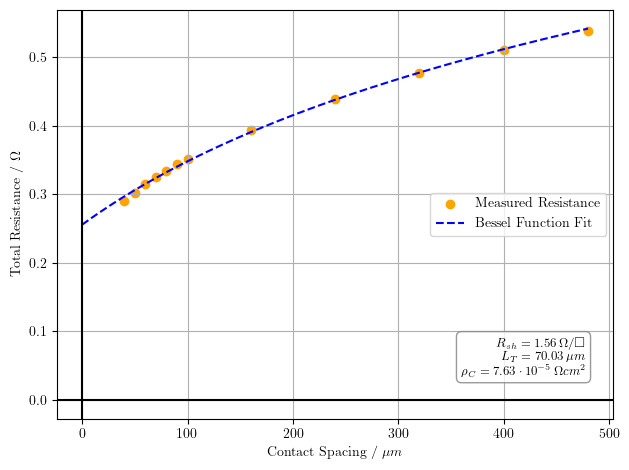

In [15]:
# @param geometries: arrays with the ditances and inner radius of the CTLM structure
# @param Rsh: sheet resistance -> initial guess
# @param Lt: transfer length -> initial guess
# this still uses the assumption of R_sh being constant under and between the contacts
def ctlm_bessel_model(geometries, Rsh, L_T):
        
        (distances, r_inner) = geometries
        # Term 1: Resistance of the semiconductor gap
        term_gap = np.log((r_inner + distances) / r_inner)
        
        # Term 2: Resistance of the inner contact (using using bessel functions I0 and I1)
        term_inner = (L_T / r_inner) * (special.i0(r_inner / L_T) / special.i1(r_inner / L_T))
        
        # Term 3: Resistance of the outer contact (using bessel functions K0 and K1)
        term_outer = (L_T / (r_inner + distances)) * (special.k0((r_inner + distances) / L_T) / special.k1((r_inner + distances) / L_T))
        
        # Total Resistance
        R_T = (Rsh / (2 * np.pi)) * (term_gap + term_inner + term_outer)

        return R_T

# Initial Guess: [Rsh, Lt]
# p0 = [R_sh_linear, L_T_linear]
p0 = [1, 100]
# p0 = [1, 1]
bounds = ([0, 0], [np.inf, np.inf])
r_inner_array = np.full_like(distances, r_inner)

popt, pcov = curve_fit(ctlm_bessel_model, (distances, r_inner_array), R_list, p0=p0, bounds=bounds)

Rsh_fit, Lt_fit = popt

rho_c_fit = Rsh_fit * (Lt_fit**2) * 1e-8  # 1e-8 to convert from ohm·μm² to ohm·cm²

distances_smooth = np.linspace(0, max(distances), 300) # min(distances)
ri_smooth = np.full_like(distances_smooth, r_inner)
Rt_fit_curve = ctlm_bessel_model((distances_smooth, ri_smooth), Rsh_fit, Lt_fit)

plt.figure()

plt.scatter(distances, R_list, color='orange', marker='o', label='Measured Resistance')
plt.plot(distances_smooth, Rt_fit_curve, color='blue', linestyle='--', label='Bessel Function Fit')

# d_fit, R_fit, R_sh_linFit, L_T_linFit, rho_C_linFit, R_intercept = fit_linear_approximation(distances, np.array(R_list), r_inner)
# plt.plot(d_fit, R_fit, color='green', linestyle='--', label='Linear Approximated Fit')

tlm_text = (
    f"$R_{{sh}} = {Rsh_fit:.2f} \\, \\Omega / \\square$\n"
    f"$L_T = {Lt_fit:.2f} \\, \\mu m$\n"
    f"$\\rho_C = {sci_notation_latex(rho_c_fit)} \\, \\Omega cm^2$"
)

plt.gca().text(
    0.95, 0.1, tlm_text,
    fontsize=9,
    transform=plt.gca().transAxes,
    verticalalignment='bottom',
    horizontalalignment='right',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8, edgecolor='gray')
)

plt.axhline(0, color='black', linewidth=1.5)
plt.axvline(0, color='black', linewidth=1.5)

# plt.title(name)
plt.xlabel("Contact Spacing / $\\mu m$")
plt.ylabel("Total Resistance / $\\Omega$")
plt.legend()
plt.tight_layout()
# plt.xlim(0, max(list_of_measurements.keys())+20)
plt.grid(True)
plt.savefig(os.path.join(folder_path, 'cTLM_plot.pdf'), dpi=300)
plt.show()